# 2.0 Machine Learning For Regression

In [1]:
import numpy as np
import pandas as pd

# 2.1 Data Preperation

In [2]:
data = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv"

In [3]:
df = pd.read_csv("../dataset-week2/data.csv")


In [4]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [5]:
df.columns = df.columns.str.lower().str.replace(" ", "_")    # data cleaning

In [6]:
df.head(3)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350


In [7]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [8]:
# here we are seperating the str datatypes
df.dtypes[df.dtypes == "str"]

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [9]:
# here we are geting the index of the str in the table and converting them to the list and storing it into a variable
strings = list(df.dtypes[df.dtypes == "str"].index)   
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [10]:
# here we are using loop to apply the cleaning to all the elements  of the strings to get cleaner dataframe
for col in strings:
    df[col] = df[col].str.lower().str.replace(" ","_")

In [11]:
df.head(3)  # here now the dataframe looks much cleaner

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350


# 2.2 Exploratory Data Analysis

In [12]:
for col in df.columns:
    print(col)                           # printing col name
    print(df[col].unique()[:5])          # printing 5 unique values from the column
    print(df[col].nunique())             # printing how many total unique values are there in the column
    print()                              # used for spacing


make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

## Distribution of price

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='msrp', ylabel='Count'>

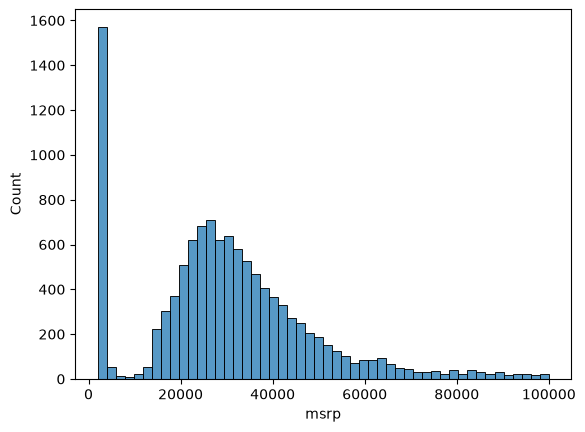

In [14]:
sns.histplot(df.msrp[df.msrp < 100000] , bins = 50)     # here bins= 50 means (how many bars we have)  # 1e^6 = 10^6 (1 million)

In [15]:
# now we cannot keep this graph as it can confuse the model aso we will use logarithmic values  (rn the graph is "Long Tail Distribution")
# and we also add 1 to the every values so we dont get the -ve log values so we use (np.log1p() function)
price_logs = np.log1p(df.msrp)
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

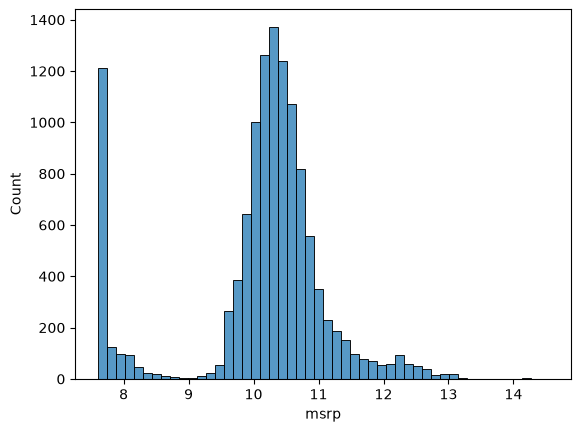

In [16]:
sns.histplot(price_logs , bins = 50)   # now the graph looks like noramal distribution so now its ideal for model training   (rn the graph is "Normal Distribution")

## Missing Values

In [17]:
df.isnull().sum()  # here we are looking for how many null values we have 

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# 2.4 Setting Up the validation framework

In [18]:
# here we spltit the dataframe in three parts 1)Train 2)validation 3)Test
n = len(df)   

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test
 # here we do this so we dont loose any values in the data set , as due to rounding we have lost some values (we clud also have used the (n_train = int(n * 0.6) but it losses some values))   

In [19]:
n_train , n_val ,n_test   # now we know the size of the dataset

(7150, 2382, 2382)

In [20]:
# Spliting the DataFrame into train, validation, and test sets using row indices
df_train = df.iloc[ : n_train]
df_val = df.iloc[ n_train : n_train + n_val]
df_test = df.iloc[ n_train + n_val : ]


In [21]:
idx = np.arange(n)    # Create a list of all row numbers before shuffling

In [22]:
# here we are suffeling the data to break any accidental order opr recurring values ,as shuffeling helps model train well
np.random.seed(2)
np.random.shuffle(idx)

In [23]:
idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [24]:
# now we are writing the shuffeled data by adding idx to the  split dataset
df_train = df.iloc[idx[  : n_train ]]
df_val = df.iloc[idx[ n_train : n_train + n_val]]
df_test = df.iloc[idx[ n_train + n_val : ]]



In [25]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [26]:
# Reset row indices to start from 0 and remove the old shuffled indices
df_train = df_train.reset_index(drop =True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

In [27]:
# Convert the target variable (MSRP) into log scale for better model performance
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [28]:
# Remove the target column (MSRP) from the feature DataFrames (so we dont accidently use it for training purpose)
del df_train["msrp"]
del df_val["msrp"]
del df_test["msrp"]

# 2.5 Linear Regression

## Linear Regression Formula

$$
\hat{y} = w_0 + \sum_{j=1}^{n} w_j x_j
$$

Where:

- $\hat{y}$ = Predicted value
- $w_0$ = Bias (Intercept)
- $w_j$ = Weight (coefficient) of the $j^{th}$ feature
- $x_j$ = Value of the $j^{th}$ feature
- $n$ = Total number of features

In [29]:
df_train.iloc[10]  # getting values of the 10 the index car from the data frame

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [30]:
xi = [453 , 11 , 86]     # writing dowm the small values from the table like  engine_hp,city_mpg ,popularity   # feature vector

In [31]:
w0 = 7.17               # bias
w = [0.01, 0.04, 0.002]        # weights

# Compute the prediction by adding the weighted contribution of each feature
def linear_regression(xi):
    n = len(xi)
    pred = w0
    for j in range(n):
        pred = pred + w[j] * xi[j]
    return pred

In [32]:
linear_regression(xi)

12.312

In [33]:
np.exp(12.312) -1       # Apply the inverse of the log1p transformation to recover the original values # we do -1 to undo the +1 we did inside the log

np.float64(222347.2221101062)

In [34]:
np.log1p(222347.2221101062)

np.float64(12.312)

#  2.6 Linear Regression Vector Form

## Linear Regression (Vector Form)

$$
\hat{y}=w_0+x^Tw
$$

Where:

- $\hat{y}$ = Predicted value
- $w_0$ = Bias (Intercept)
- $x$ = Feature vector
- $w$ = Weight vector
- $x^T$ = Transpose of the feature vector
- $x^Tw$ = Dot product (weighted sum of all features)

In [35]:
def dot(xi , w): 
    n = len(xi)
    res = 0.0
    for j in range(n):
        res = res + w[j] * w[j]
    return res

In [36]:
def linear_regression(xi):
    return w0 + dot(xi , w)

In [37]:
w_new = [w0] + w

In [38]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [39]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi , w_new)

In [40]:
linear_regression(xi)

51.410604

In [41]:
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [42]:
x1 = [ 1 , 148 , 24, 1385]
x2 = [ 1 , 132 , 25, 2031]
x10 = [1 , 453 , 11, 86]

X = [x1 , x2 ,x10]
X = np.array(X)

# 2.7 Training A linear Regression Model

## Notes

- The **Normal Equation** is a closed-form solution used to compute the optimal weights for a Linear Regression model.
- It directly calculates the coefficients that minimize the Mean Squared Error (MSE) on the training data.
- The feature matrix is represented by **X**, the target values by **y**, and the learned weights by **w**.

### Normal Equation

$$
w = (X^TX)^{-1}X^Ty
$$

Where:

- $X$ = Feature matrix
- $X^T$ = Transpose of the feature matrix
- $(X^TX)^{-1}$ = Inverse of $X^TX$
- $y$ = Target vector
- $w$ = Optimal weight vector

> **Note:** In practice, we usually don't compute this equation manually. Libraries such as **scikit-learn** calculate the model parameters using optimized numerical algorithms. The Normal Equation is studied to understand the mathematical foundation of Linear Regression.

In [43]:
def train_linear_regression(X, y):
    pass
 

In [44]:
X = [  
    [148 , 24, 1385],
    [132 , 25, 2031],
    [453 , 11, 86],
    [158 , 24, 185],
    [172 , 25, 201],
    [413 , 11, 86],
    [38,   54, 185],
    [142 , 25, 431],
    [453 , 31, 86]
    ]


X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [45]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [46]:
X = np.column_stack([ ones , X])   # here wea rae ading ones to all the clomun in the first place of all the rows with the help  of numpy function called np.column_stack([ ])

In [47]:
y = [10000 , 20000, 15000 ,20050 ,10000, 20000 ,15000 ,25000 , 12000]

In [48]:
XTX = X.T.dot(X)

In [49]:
XTX_inv = np.linalg.inv(XTX)

In [50]:
w_full = XTX_inv.dot(X.T).dot(y)

In [51]:
w0 = w_full[0]
w = w_full[1 :]

In [52]:
w0 ,w

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [53]:
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ ones , X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0] , w_full[1 :]


# 2.8 Car Price Baseline Model

In [54]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [55]:
base = ["engine_hp" ,"engine_cylinders" , "highway_mpg" , "city_mpg", "popularity"]
df_train[base] # used for getting  the subset of the columns

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,148.0,4.0,33,24,1385
1,132.0,4.0,32,25,2031
2,148.0,4.0,37,28,640
3,90.0,4.0,18,16,873
4,385.0,8.0,21,15,5657
...,...,...,...,...,...
7145,300.0,6.0,31,20,3916
7146,210.0,4.0,30,24,873
7147,285.0,6.0,22,17,549
7148,563.0,12.0,21,13,86


In [56]:
X_train = df_train[base].values
y_train 

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [57]:
X_train = df_train[base].fillna(0).values       # heare we are filling NAN(misiing values ) with zeros using the function .fillna(value)

In [58]:
w0 , w = train_linear_regression(X_train,y_train)

In [59]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

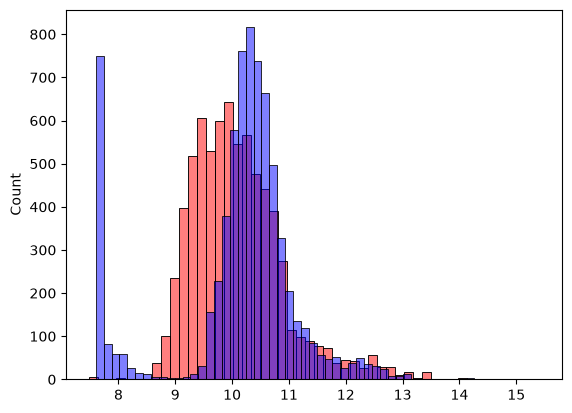

In [60]:
sns.histplot(y_pred , color ="red" , alpha = 0.5 , bins =50)
sns.histplot(y_train , color ='blue' ,alpha = 0.5 , bins =50)


# 2.9 RMSE   (Root Mean Squared Error)

# Root Mean Squared Error (RMSE)

RMSE (Root Mean Squared Error) is an **evaluation metric** used to measure how well a regression model predicts the target values.

It calculates the average prediction error by:
1. Computing the difference between the actual and predicted values.
2. Squaring each error.
3. Taking the mean of the squared errors (MSE).
4. Taking the square root of the MSE.

## Formula

$$
RMSE=\sqrt{\frac{1}{m}\sum_{i=1}^{m}\left(g(x_i)-y_i\right)^2}
$$

Where:

- $g(x_i)$ = Predicted value for the $i^{th}$ sample
- $y_i$ = Actual value for the $i^{th}$ sample
- $m$ = Total number of samples



## Interpretation

- **RMSE = 0** → Perfect predictions.
- **Lower RMSE** → Better model performance.
- **Higher RMSE** → Larger prediction errors.

> **Note:** RMSE has the same unit as the target variable, making it easy to interpret. It is one of the most commonly used evaluation metrics for regression models.

In [61]:
# RMSE python Implementation
def rmse(y, y_pred):
    error = y - y_pred
    squared_error = (error) ** 2
    mean_squared_error = squared_error.mean()
    return np.sqrt(mean_squared_error)


In [62]:
rmse(y_train,y_pred)

np.float64(0.7554192603920132)

# 2.10 Validating the Model

In [63]:
base = ["engine_hp" ,"engine_cylinders" , "highway_mpg" , "city_mpg", "popularity"]
X_train = df_train[base].fillna(0).values 
w0 , w = train_linear_regression(X_train,y_train)
y_pred = w0 + X_train.dot(w)

In [64]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [65]:
X_train = prepare_X(df_train)
w0 , w = train_linear_regression(X_train , y_train)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val , y_pred)

np.float64(0.761653099130156)

# 2.11 Simple Feature Engineering

# Feature Engineering

Feature Engineering is the process of creating new features from existing data to improve the performance of a machine learning model.

### Example

Original Feature:

- `year`

New Feature:

```python
age = 2017 - year
```

The model learns better from the **age of the car** than from the manufacturing year.

### Why?

- Creates more meaningful input features.
- Helps the model capture relationships more effectively.
- Can improve prediction accuracy (lower RMSE).

> **Key Idea:** Better features often lead to better model performance.

In [66]:
2017 - df_train.year

0        9
1        5
2        1
3       26
4        0
        ..
7145     2
7146     2
7147     2
7148     3
7149     0
Name: year, Length: 7150, dtype: int64

In [67]:
def prepare_X(df):
    df = df.copy()
    df["age"] = 2017 - df.year
    features  = base + ['age']
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [68]:
X_train = prepare_X(df_train)
w0 , w = train_linear_regression(X_train , y_train)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val , y_pred)

np.float64(0.5172055461058299)

<Axes: ylabel='Count'>

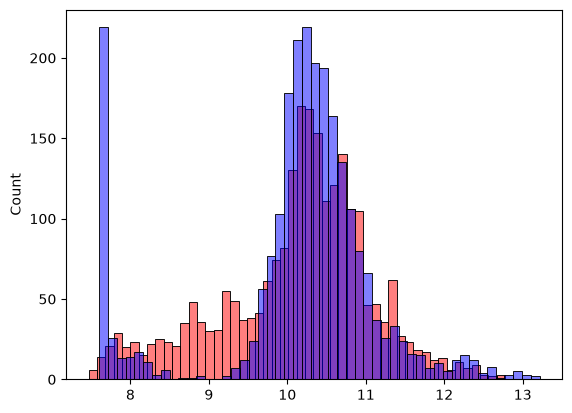

In [69]:
sns.histplot(y_pred , color ="red" , alpha = 0.5 , bins =50)
sns.histplot(y_val , color ='blue' ,alpha = 0.5 , bins =50)

# 2.12 Categorical Variables

In [70]:
"num_of_doors_%s" % 4   # string tempelate 

'num_of_doors_4'

In [71]:
# we write it in the loop instead of manually writting it

for v in [ 2, 3, 4]:
    df_train["num_of_doors_%s" % v] = (df_train.number_of_doors == v).astype("int")

In [72]:
def prepare_X(df):
    df = df.copy()
    df["age"] = 2017 - df.year
    features  = base + ['age']

    for v in [ 2, 3, 4]:
        df["num_of_doors_%s" % v] = (df.number_of_doors == v).astype("int")
        features.append("num_of_doors_%s" % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [73]:
X_train = prepare_X(df_train)
w0 , w = train_linear_regression(X_train , y_train)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val , y_pred)

np.float64(0.515799564150169)

In [74]:
makes = list(df.make.value_counts().head().index)
makes

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [75]:
def prepare_X(df):
    df = df.copy()
    df["age"] = 2017 - df.year
    features  = base + ['age']

    for v in [ 2, 3, 4]:
        df["num_of_doors_%s" % v] = (df.number_of_doors == v).astype("int")
        features.append("num_of_doors_%s" % v)
    
    for v in makes:
        df["make_%s" % v] = (df.make == v).astype("int")
        features.append("make_%s" % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [76]:
X_train = prepare_X(df_train)
w0 , w = train_linear_regression(X_train , y_train)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val , y_pred)

np.float64(0.5076038849556795)

In [77]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
num_of_doors_2         int64
num_of_doors_3         int64
num_of_doors_4         int64
dtype: object

In [78]:
categorical_values = [ "make" , "engine_fuel_type", "transmission_type", "driven_wheels", "market_category", "vehicle_size", "vehicle_style"]

In [79]:
categories = {}
for c in categorical_values:
    categories[c] = list(df[c].value_counts().head().index)


In [80]:
categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [81]:
def prepare_X(df):
    df = df.copy()
    df["age"] = 2017 - df.year
    features  = base + ['age']

    for v in [ 2, 3, 4]:
        df["num_of_doors_%s" % v] = (df.number_of_doors == v).astype("int")
        features.append("num_of_doors_%s" % v)
    
    for c ,values in categories.items():
        for v in values:
            df["%s_ %s" % (c,v)] = (df[c] == v).astype("int")
            features.append("%s_ %s" % (c,v))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [82]:
X_train = prepare_X(df_train)
w0 , w = train_linear_regression(X_train , y_train)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val , y_pred)

np.float64(23.019020704791835)

# 2.13 Regularisation

In [93]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4.00001],
    [7, 5, 5],
    [4, 5, 5.00000001],
]

X = np.array(X)
X

array([[4.        , 4.        , 4.        ],
       [3.        , 5.        , 5.        ],
       [5.        , 1.        , 1.        ],
       [5.        , 4.        , 4.00001   ],
       [7.        , 5.        , 5.        ],
       [4.        , 5.        , 5.00000001]])

In [99]:
y= [1, 2, 3, 1, 2, 3]

In [100]:
XTX = X.T.dot(X)

In [101]:
XTX

array([[140.        , 111.        , 111.00005004],
       [111.        , 108.        , 108.00004005],
       [111.00005004, 108.00004005, 108.0000801 ]])

In [102]:
XTX_INV = np.linalg.inv(XTX)

In [106]:
XTX = [
    [1, 2, 2],
    [2, 1, 1.0000001],
    [2, 1.0000001, 1]
]

XTX = np.array(XTX)

In [107]:
np.linalg.inv(XTX)

array([[-3.33333356e-01,  3.33333339e-01,  3.33333339e-01],
       [ 3.33333339e-01, -5.00000008e+06,  4.99999991e+06],
       [ 3.33333339e-01,  4.99999991e+06, -5.00000008e+06]])

In [108]:
XTX = XTX + 0.01 * np.eye(3)

In [109]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [110]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.45652199012897743)

# 2.14 Tuning the model

In [113]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(r, w0, score)

0.0 4011091003551887.0 23.019020704791835
1e-05 6.178192055025445 0.45651702823445617
0.0001 6.317246071243372 0.4565170654323052
0.001 6.285636717989048 0.45651750867781377
0.1 6.1912087238544915 0.4565692763007501
1 5.634896668066369 0.45722043179930605
10 4.283980108968471 0.4701456932099909


In [117]:
r = 0.0001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score

np.float64(0.45652199012897743)

# 2.15 Using The Model

In [120]:
df_full_train = pd.concat([df_train , df_val])

In [121]:
df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_of_doors_2,num_of_doors_3,num_of_doors_4
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1.0,0.0,0.0
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0.0,0.0,1.0
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0.0,0.0,1.0
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0.0,1.0,0.0
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,volvo,v60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,wagon,37,25,870,NaN,NaN,NaN
2378,maserati,granturismo_convertible,2015,premium_unleaded_(required),444.0,8.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,20,13,238,NaN,NaN,NaN
2379,cadillac,escalade_hybrid,2013,regular_unleaded,332.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,hybrid",large,4dr_suv,23,20,1624,NaN,NaN,NaN
2380,mitsubishi,lancer,2016,regular_unleaded,148.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,34,24,436,NaN,NaN,NaN


In [124]:
df_full_train = df_full_train.reset_index(drop=True)

In [125]:
df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_of_doors_2,num_of_doors_3,num_of_doors_4
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1.0,0.0,0.0
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0.0,0.0,1.0
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0.0,0.0,1.0
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0.0,1.0,0.0
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,volvo,v60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,wagon,37,25,870,NaN,NaN,NaN
9528,maserati,granturismo_convertible,2015,premium_unleaded_(required),444.0,8.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,20,13,238,NaN,NaN,NaN
9529,cadillac,escalade_hybrid,2013,regular_unleaded,332.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,hybrid",large,4dr_suv,23,20,1624,NaN,NaN,NaN
9530,mitsubishi,lancer,2016,regular_unleaded,148.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,34,24,436,NaN,NaN,NaN


In [126]:
X_full_train = prepare_X(df_full_train)

In [127]:
X_full_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 41))

In [128]:
y_full_train = np.concatenate([y_train,y_val])

In [129]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [130]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.45177493106214056)

In [131]:
car = df_test.iloc[20].to_dict()
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [132]:
df_small = pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [133]:
X_small = prepare_X(df_small)

In [134]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(10.462651700289744)

In [135]:
np.expm1(y_pred)

np.float64(34983.19616272936)

In [136]:
np.expm1(y_test[20])

np.float64(35000.00000000001)